# Variational Autoencoder: A Two-Dimensional MNIST Latent Space

## Goal

Train a variational autoencoder (VAE) from scratch, separate reconstruction and
KL-divergence losses, inspect held-out reconstructions, and map a two-dimensional
latent space into generated digits.

This is a compact PyTorch reimplementation of the course VAE idea. It keeps the
official train/test split intact and batch-decodes the latent grid.

## Setup

Install `requirements-course-demos.txt`. The first run downloads MNIST through
`torchvision` into the ignored `data/` directory. The dataset and trained weights
are not committed. Training is intentionally CPU-friendly and deterministic.

In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
DEVICE = torch.device("cpu")

print(f"torch={torch.__version__}; device={DEVICE}; seed={SEED}")

torch=2.14.0; device=cpu; seed=42


## Steps

### 1. Load MNIST and preview the training data

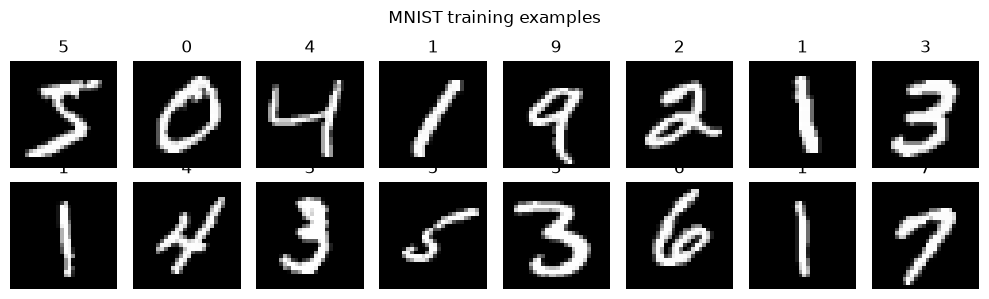

train=60,000; test=10,000; image shape=(1, 28, 28)


In [2]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST("data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST("data", train=False, download=True, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    num_workers=0,
)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for axis, (image, label) in zip(axes.flat, train_dataset):
    axis.imshow(image.squeeze(), cmap="gray")
    axis.set_title(str(label))
    axis.axis("off")
fig.suptitle("MNIST training examples")
plt.tight_layout()
plt.show()

print(f"train={len(train_dataset):,}; test={len(test_dataset):,}; image shape={tuple(train_dataset[0][0].shape)}")

### 2. Define the encoder, reparameterization step, and decoder

The encoder predicts a mean and log-variance. Sampling uses
`z = mean + standard_deviation × noise`, which keeps the stochastic path
differentiable during training.

In [3]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dimension=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
        )
        self.mean_layer = nn.Linear(256, latent_dimension)
        self.log_variance_layer = nn.Linear(256, latent_dimension)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dimension, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),
        )

    def encode(self, images):
        hidden = self.encoder(images)
        return self.mean_layer(hidden), self.log_variance_layer(hidden)

    def reparameterize(self, mean, log_variance):
        standard_deviation = torch.exp(0.5 * log_variance)
        return mean + standard_deviation * torch.randn_like(standard_deviation)

    def decode(self, latent):
        return self.decoder(latent).reshape(-1, 1, 28, 28)

    def forward(self, images):
        mean, log_variance = self.encode(images)
        latent = self.reparameterize(mean, log_variance)
        return self.decode(latent), mean, log_variance


vae = VariationalAutoencoder(latent_dimension=2).to(DEVICE)
trainable_parameters = sum(parameter.numel() for parameter in vae.parameters() if parameter.requires_grad)
print(f"trainable parameters={trainable_parameters:,}")

trainable parameters=404,244


### 3. Train with reconstruction and KL-divergence losses

In [4]:
def vae_loss(reconstruction, images, mean, log_variance):
    reconstruction_loss = F.binary_cross_entropy(reconstruction, images, reduction="sum") / len(images)
    kl_loss = -0.5 * torch.sum(1 + log_variance - mean.pow(2) - log_variance.exp()) / len(images)
    return reconstruction_loss + kl_loss, reconstruction_loss, kl_loss


optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
history = []

for epoch in range(8):
    vae.train()
    totals = {"total": 0.0, "reconstruction": 0.0, "kl": 0.0}
    for images, _ in train_loader:
        images = images.to(DEVICE)
        reconstruction, mean, log_variance = vae(images)
        total_loss, reconstruction_loss, kl_loss = vae_loss(
            reconstruction, images, mean, log_variance
        )
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        batch_size = len(images)
        totals["total"] += total_loss.item() * batch_size
        totals["reconstruction"] += reconstruction_loss.item() * batch_size
        totals["kl"] += kl_loss.item() * batch_size

    history.append(
        {
            "epoch": epoch + 1,
            **{name: value / len(train_dataset) for name, value in totals.items()},
        }
    )

history_frame = pd.DataFrame(history)
history_frame.style.format({"total": "{:.2f}", "reconstruction": "{:.2f}", "kl": "{:.2f}"})

,epoch,total,reconstruction,kl
0,1,211.53,203.89,7.64
1,2,177.60,171.83,5.76
2,3,170.84,165.36,5.48
3,4,167.06,161.61,5.45
4,5,164.90,159.47,5.42
5,6,163.32,157.89,5.44
6,7,162.17,156.71,5.46
7,8,161.21,155.73,5.48


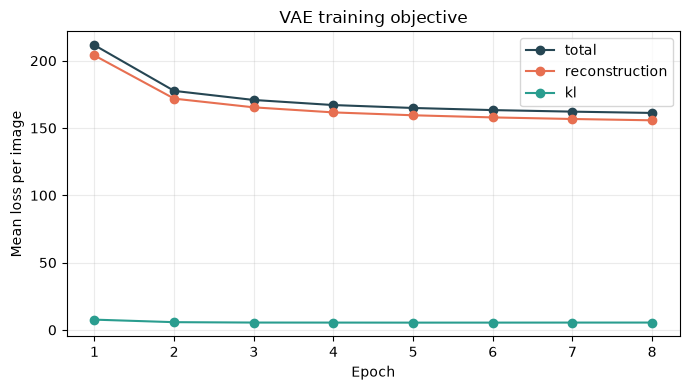

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for column, color in [("total", "#264653"), ("reconstruction", "#e76f51"), ("kl", "#2a9d8f")]:
    ax.plot(history_frame["epoch"], history_frame[column], marker="o", label=column, color=color)
ax.set(xlabel="Epoch", ylabel="Mean loss per image", title="VAE training objective")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 4. Reconstruct held-out digits using the latent mean

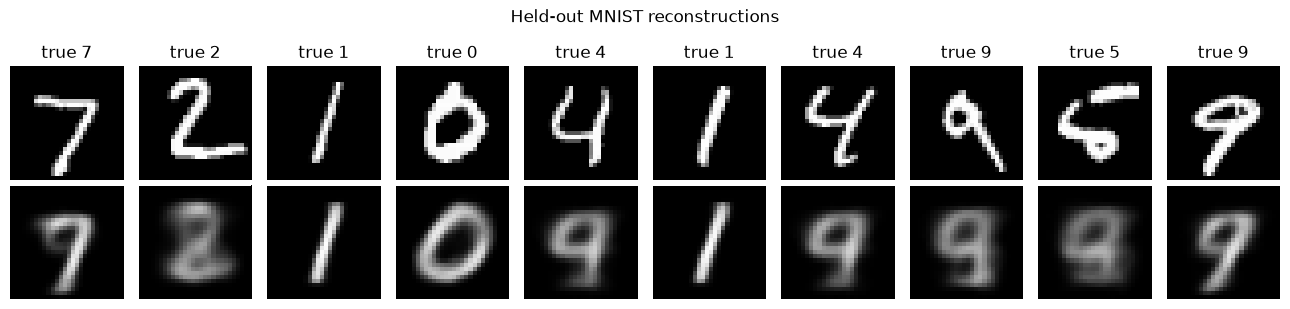

In [6]:
vae.eval()
test_images, test_labels = next(iter(test_loader))
with torch.no_grad():
    test_mean, test_log_variance = vae.encode(test_images.to(DEVICE))
    deterministic_reconstruction = vae.decode(test_mean).cpu()

fig, axes = plt.subplots(2, 10, figsize=(13, 3.2))
for index in range(10):
    axes[0, index].imshow(test_images[index].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, index].set_title(f"true {test_labels[index].item()}")
    axes[1, index].imshow(deterministic_reconstruction[index].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, index].axis("off")
    axes[1, index].axis("off")
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("reconstruction")
fig.suptitle("Held-out MNIST reconstructions")
plt.tight_layout()
plt.show()

### 5. Inspect the latent space and decode a continuous grid

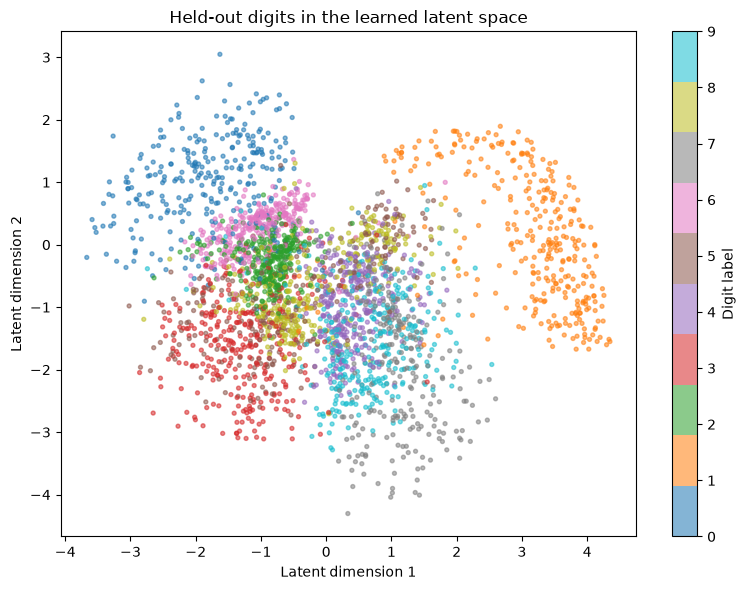

In [7]:
latent_means = []
latent_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        mean, _ = vae.encode(images.to(DEVICE))
        latent_means.append(mean.cpu())
        latent_labels.append(labels)

latent_means = torch.cat(latent_means).numpy()
latent_labels = torch.cat(latent_labels).numpy()
sample_indices = np.random.default_rng(SEED).choice(len(latent_means), size=3000, replace=False)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    latent_means[sample_indices, 0],
    latent_means[sample_indices, 1],
    c=latent_labels[sample_indices],
    cmap="tab10",
    s=8,
    alpha=0.55,
)
colorbar = fig.colorbar(scatter, ax=ax, ticks=range(10))
colorbar.set_label("Digit label")
ax.set(xlabel="Latent dimension 1", ylabel="Latent dimension 2", title="Held-out digits in the learned latent space")
plt.tight_layout()
plt.show()

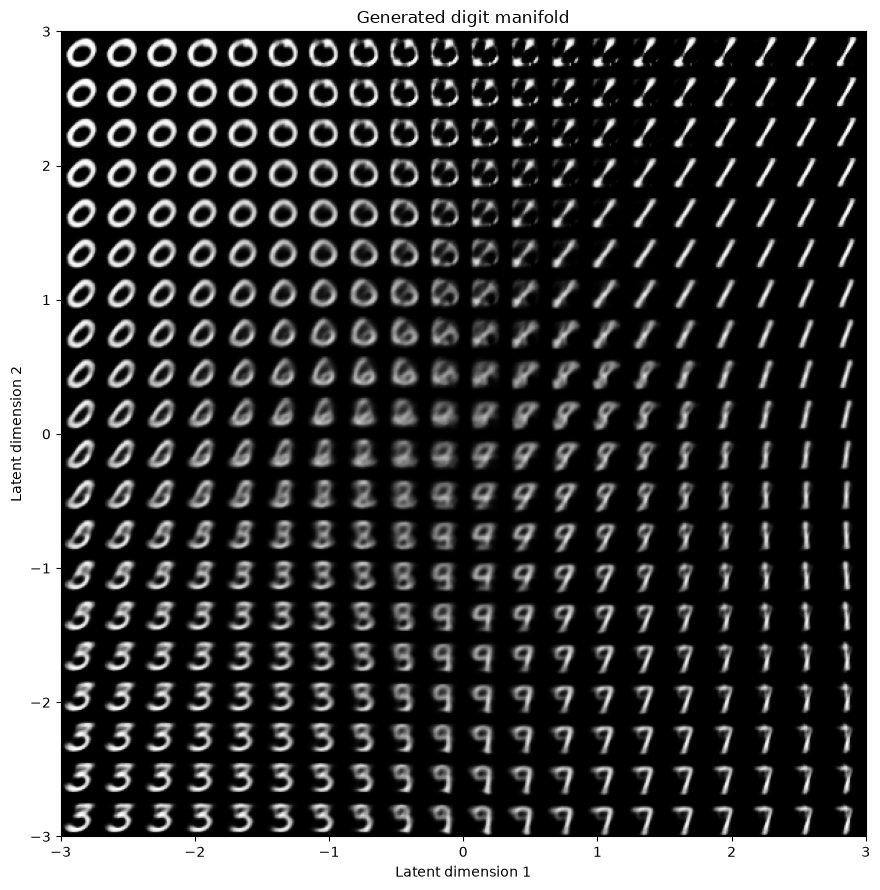

In [8]:
grid_size = 20
grid_axis = np.linspace(-3.0, 3.0, grid_size)
grid_x, grid_y = np.meshgrid(grid_axis, grid_axis[::-1])
latent_grid = torch.tensor(
    np.column_stack([grid_x.ravel(), grid_y.ravel()]), dtype=torch.float32, device=DEVICE
)

with torch.no_grad():
    decoded_grid = vae.decode(latent_grid).cpu().numpy()[:, 0]

manifold = np.zeros((28 * grid_size, 28 * grid_size))
for index, digit in enumerate(decoded_grid):
    row, column = divmod(index, grid_size)
    manifold[row * 28 : (row + 1) * 28, column * 28 : (column + 1) * 28] = digit

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(manifold, cmap="gray", extent=[-3, 3, -3, 3])
ax.set(xlabel="Latent dimension 1", ylabel="Latent dimension 2", title="Generated digit manifold")
plt.tight_layout()
plt.show()

## Checks

In [9]:
assert len(train_dataset) == 60_000 and len(test_dataset) == 10_000
assert history_frame["total"].notna().all()
assert history_frame["total"].iloc[-1] < 0.90 * history_frame["total"].iloc[0]
assert deterministic_reconstruction.shape == test_images.shape
assert 0.0 <= deterministic_reconstruction.min().item() <= deterministic_reconstruction.max().item() <= 1.0
assert latent_means.shape == (10_000, 2)
assert np.isfinite(manifold).all()

print(
    f"Checks passed: total loss {history_frame['total'].iloc[0]:.2f} → "
    f"{history_frame['total'].iloc[-1]:.2f}; held-out latent shape={latent_means.shape}."
)

Checks passed: total loss 211.53 → 161.21; held-out latent shape=(10000, 2).


## Next Steps

- Increase latent dimensionality and compare reconstruction quality with interpretability.
- Try a beta-VAE to change the strength of the KL regularizer.
- Condition the decoder on labels to request a particular digit.
- Evaluate samples quantitatively instead of judging only a visually appealing manifold.

A smooth latent map is evidence that this model learned a useful compression of
MNIST. It is not evidence that every generated digit is realistic or that the
representation will transfer to other image domains.